# Penguin Clustering with K-Means
A simple unsupervised learning practical using the Palmer Penguins dataset.

## Goal
Group penguins using their body measurements and check whether the clusters show a clear pattern.

## 1. Setup

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
colors = ["#2563EB", "#F59E0B", "#DB2777"]

## 2. Load the data
We first load the dataset and look at a few rows.

In [2]:
penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
print(f"Rows: {penguins.shape[0]} | Columns: {penguins.shape[1]}")
penguins.isna().sum().to_frame("Missing values")

Rows: 344 | Columns: 7


,Missing values
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


## 3. Explore the measurements
This chart shows how species overlap across two useful measurements.

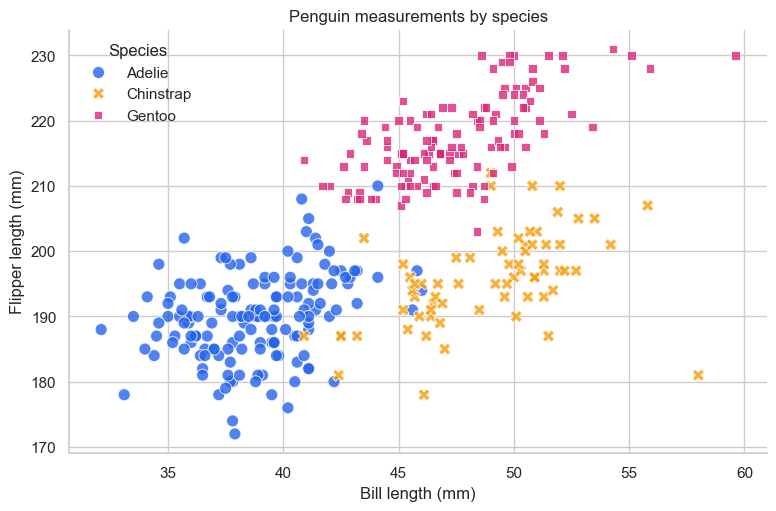

In [4]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.scatterplot(data=penguins, x="bill_length_mm", y="flipper_length_mm",
                hue="species", style="species", palette=colors, s=75, alpha=0.8, ax=ax)
ax.set(title="Penguin measurements by species", xlabel="Bill length (mm)",
       ylabel="Flipper length (mm)")
ax.legend(title="Species", frameon=False)
sns.despine()
plt.show()

## 4. Prepare the data
K-Means needs complete numeric data. The measurements are also scaled so that larger units do not dominate the model.

In [5]:
features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
model_data = penguins[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(model_data)
print(f"Rows used for clustering: {len(model_data)}")

Rows used for clustering: 342


## 5. Choose the number of clusters
The elbow method compares how much variation remains as more clusters are added.

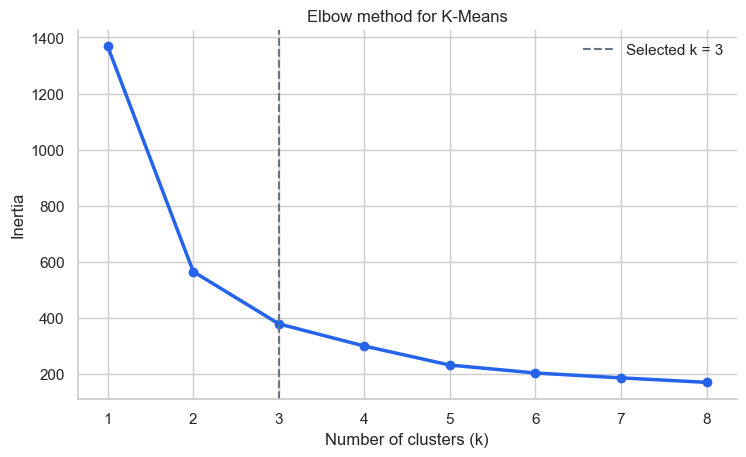

In [6]:
k_values = range(1, 9)
inertia = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled).inertia_ for k in k_values]

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(k_values, inertia, color=colors[0], marker="o", linewidth=2.5)
ax.axvline(3, color="#64748B", linestyle="--", label="Selected k = 3")
ax.set(title="Elbow method for K-Means", xlabel="Number of clusters (k)", ylabel="Inertia", xticks=list(k_values))
ax.legend(frameon=False)
sns.despine()
plt.show()

The curve begins to flatten around **3 clusters**, so I will use `k = 3`.

## 6. Fit the model

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

results = model_data.copy()
results["cluster"] = clusters
results["species"] = penguins.loc[model_data.index, "species"]
pd.crosstab(results["cluster"], results["species"], margins=True)

species,Adelie,Chinstrap,Gentoo,All
cluster,,,,
0,24,63,0,87
1,0,0,123,123
2,127,5,0,132
All,151,68,123,342


## 7. Visualise the clusters
PCA reduces the four measurements to two dimensions, making the cluster pattern easier to see.

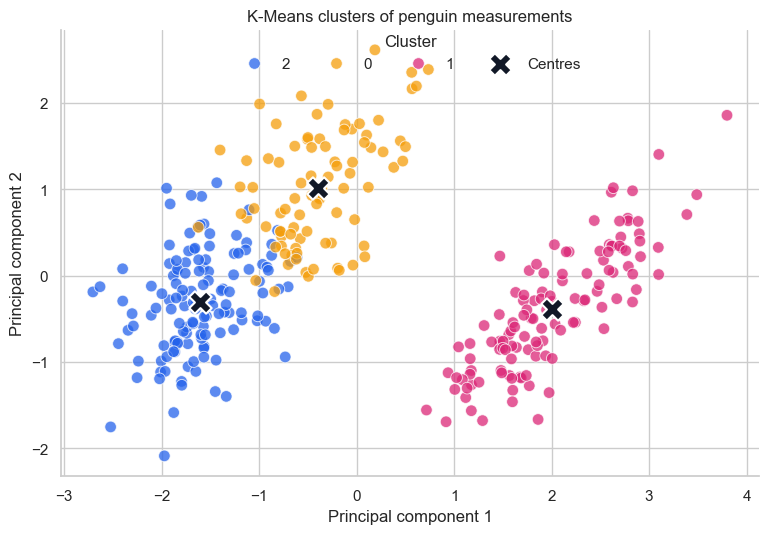

In [8]:
pca = PCA(n_components=2)
points_2d = pca.fit_transform(X_scaled)
centres_2d = pca.transform(kmeans.cluster_centers_)

plot_data = pd.DataFrame(points_2d, columns=["PC1", "PC2"])
plot_data["Cluster"] = clusters.astype(str)

fig, ax = plt.subplots(figsize=(9, 5.8))
sns.scatterplot(data=plot_data, x="PC1", y="PC2", hue="Cluster",
                palette=colors, s=70, alpha=0.75, ax=ax)
ax.scatter(centres_2d[:, 0], centres_2d[:, 1], marker="X", s=260,
           color="#111827", edgecolor="white", linewidth=1.5, label="Centres")
ax.set(title="K-Means clusters of penguin measurements",
       xlabel="Principal component 1", ylabel="Principal component 2")
ax.legend(title="Cluster", frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.02))
sns.despine()
plt.show()

## Takeaways
- Three clusters give a useful summary of the measurement patterns.
- The clusters are fairly distinct, although they do not match species perfectly.
- K-Means found these groups using measurements only; species was used later for comparison.